In [81]:
library(tidyverse)
library(countrycode)

gdp2019 <- read_csv(
  "https://raw.githubusercontent.com/feb-sofia/econometrics-2023/main/data/gdpgov2019.csv"
  ) |>
  mutate(
    isocode = countrycode(country, origin = "country.name", destination = "iso3c")
  )


dt <- read_csv2("https://raw.githubusercontent.com/febse/econ2026/refs/heads/main/data/rugged.csv")  |>
    filter(!is.na(rgdppc_2000)) |>
    mutate(
        # gdppc_B = rgdppc_2000,
        # gdppc = gdppc_B / 1000,
        rugged = as.numeric(rugged),
        cont = cont_africa + 2 * cont_asia + 3 * cont_europe + 4 * cont_north_america + 5 * cont_south_america + 6 * cont_oceania,
        cont = factor(cont, levels = 1:6, labels = c("Africa", "Asia", "Europe", "North America", "South America", "Oceania")),
        contIsAfrica = cont_africa
    ) |>
    select(-country)


# dt |> arrange(gdppc) |> write_csv("data/rugged_tmp.csv")
dt <- dt |> left_join(gdp2019, by = "isocode") |>
    select(isocode, country, rugged, cont, cont, contIsAfrica, gdppc) |>
    filter(!is.na(gdppc))

dt |> head()

Rows: 198 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): country
dbl (3): year, gdppc, spending

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `isocode = countrycode(country, origin = "country.name",
  destination = "iso3c")`.
Caused by warning:
! Some values were not matched unambiguously: Caribbean, East Asia, Eastern Europe, Kosovo, North Africa, Sub-Saharan Africa
To fix unmatched values, please use the `custom_match` argument. If you think the default matching rules should be improved, please file an issue at https://github.com/vincentarelbundock/countrycode/issues”
ℹ Using "','" as decimal and "'.'" as grouping mark. Use `read_delim()` for more control.

Rows: 234 Columns: 51
── Column specification ────────────────────────────────────────

isocode,country,rugged,cont,contIsAfrica,gdppc
<chr>,<chr>,<dbl>,<fct>,<dbl>,<dbl>
AGO,Angola,0.858,Africa,1,2612.246
ALB,Albania,3.427,Europe,0,5345.058
ARE,United Arab Emirates,0.769,Asia,0,43981.605
ARG,Argentina,0.775,South America,0,10054.023
ARM,Armenia,2.688,Asia,0,4596.861
ATG,Antigua and Barbuda,0.006,North America,0,17495.760


`geom_smooth()` using formula = 'y ~ x'


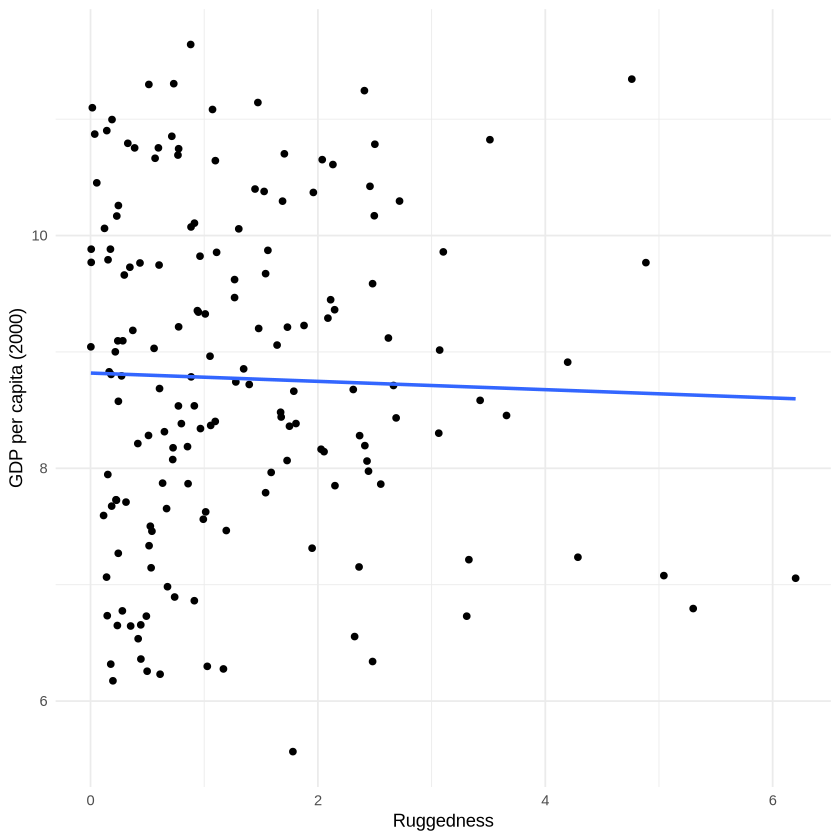

In [82]:
dt |>
    ggplot(aes(x = rugged, y = log(gdppc))) +
    geom_point() +
    geom_smooth(method = "lm", se = FALSE) +
    labs(
        x = "Ruggedness",
        y = "GDP per capita (2000)"
    ) + 
    theme_minimal()

## Categorical Variables and Dummy Variables

In the context of data analysis and machine learning, categorical variables are variables that represent distinct categories or groups, e.g. continent in our example (Africa, Asia, etc.). To use such variables in a regression model, we could map the categories to numerical values but any mapping would be arbitrary and could lead to incorrect interpretations. For example, if we assign 0 to "Africa", 1 to "Asia", 2 to "Europe", and 3 to "South America" we would imply that a country in Europe is somehow twice as much as a country in Africa, which is hardly meaningful.

Another way to include categorical variables in a regression model is to create indicator variables (often called dummy variables) for each category. Let's try this with the continent variable, but for the sake of simplicity we will focus on only three categories: Africa, Asia, and Other. We can create three dummy variables as follows:

- `IsAfrica`: 1 if the country is in Africa, 0 otherwise
- `IsAsia`: 1 if the country is in Asia, 0 otherwise
- `IsOther`: 1 if the country is in Other, 0 otherwise

Now a regression model including these dummies would look like this:

$$
\text{gdppc}_i = \beta_0 + \beta_1 \text{IsAfrica}_i + \beta_2 \text{IsAsia}_i + \beta_3 \text{IsOther}_i + e_i
$$

However, there is a problem with this approach that stems from the fact that the three indicator variables sum up to one for each observation.

$$
\text{IsAfrica}_i + \text{IsAsia}_i + \text{IsOther}_i = 1
$$

Therefore we could express one of the indicators, e.g. `IsOther`, as

$$
\text{IsOther}_i = 1 - \text{IsAfrica}_i - \text{IsAsia}_i
$$

and substitute it into the regression equation to get

$$
\text{gdppc}_i = \beta_0 + \beta_1 \text{IsAfrica}_i + \beta_2 \text{IsAsia}_i + \beta_3 (1 - \text{IsAfrica}_i - \text{IsAsia}_i) + e_i
$$

This can be rearranged to

$$
\text{gdppc}_i = (\beta_0 + \beta_3) + (\beta_1 - \beta_3) \text{IsAfrica}_i + (\beta_2 - \beta_3) \text{IsAsia}_i + e_i
$$

This means that the regression model with three dummies is equivalent to a regression model with only two dummies and a different intercept. In other words, we cannot separate (identify) the effect of the `IsOther` category from the intercept.
The implication of this is that we can choose which category to omit and what to estimate. A very common approach is to set the coefficient of the omitted category to zero. In our example, we could omit the `IsOther` category and estimate the following regression model:

$$
\text{gdppc}_i = \beta_0 + \beta_1 \text{IsAfrica}_i + \beta_2 \text{IsAsia}_i + e_i
$$

To see what we are actually estimating in terms of averages, take the conditional expectation of the dependent variable given the values of the independent variables:

$$
\begin{align*}
E[\text{gdppc}_i | \text{Continent}_i = \text{Africa}] &= \beta_0 + \beta_1 \\
E[\text{gdppc}_i | \text{Continent}_i = \text{Asia}] &= \beta_0 + \beta_2 \\
E[\text{gdppc}_i | \text{Continent}_i = \text{Other}] &= \beta_0
\end{align*}
$$


In [1]:
contr.treatment(4)

,2,3,4
1,0,0,0
2,1,0,0
3,0,1,0
4,0,0,1


In [91]:
fit_main <- lm(gdppc ~ cont, data = dt)
fit_main |> summary()


Call:
lm(formula = gdppc ~ cont, data = dt)

Residuals:
   Min     1Q Median     3Q    Max 
-30039 -10935  -1835   2492  80028 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)           2607       2555   1.021 0.308971    
contAsia             12924       3794   3.407 0.000832 ***
contEurope           31120       3849   8.085 1.49e-13 ***
contNorth America    13226       4457   2.968 0.003466 ** 
contSouth America     5471       5866   0.933 0.352440    
contOceania          12504       6698   1.867 0.063785 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 17510 on 159 degrees of freedom
Multiple R-squared:  0.2981,	Adjusted R-squared:  0.276 
F-statistic: 13.51 on 5 and 159 DF,  p-value: 5.572e-11


In [100]:
dt |> 
    group_by(cont) |>
    summarise(
        mean_gdppc = mean(gdppc),
        mean_log_gdppc = mean(log(gdppc)),
        mean_rugged = mean(rugged)
    )

cont,mean_gdppc,mean_log_gdppc,mean_rugged
<fct>,<dbl>,<dbl>,<dbl>
Africa,2607.421,7.375548,1.0860851
Asia,15531.542,8.878482,1.7559231
Europe,33727.159,10.084534,1.3059459
North America,15833.185,9.246562,1.3355652
South America,8078.187,8.861206,0.8587273
Oceania,15111.326,8.884157,1.3606250


In [96]:
33727.159 / 2607.421

[1] 12.93506

In [98]:
2607.421 * 270 / 100

[1] 7040.037

In [99]:
fit_main <- lm(log(gdppc) ~ cont, data = dt)
fit_main |> summary()


Call:
lm(formula = log(gdppc) ~ cont, data = dt)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.32414 -0.72069 -0.06723  0.69982  2.42658 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)         7.3755     0.1510  48.842  < 2e-16 ***
contAsia            1.5029     0.2242   6.702 3.38e-10 ***
contEurope          2.7090     0.2275  11.906  < 2e-16 ***
contNorth America   1.8710     0.2634   7.102 3.88e-11 ***
contSouth America   1.4857     0.3468   4.284 3.16e-05 ***
contOceania         1.5086     0.3959   3.810 0.000198 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.035 on 159 degrees of freedom
Multiple R-squared:  0.4861,	Adjusted R-squared:   0.47 
F-statistic: 30.08 on 5 and 159 DF,  p-value: < 2.2e-16
